In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
## general libraries
import pathlib
from rich.pretty import install, pprint

## data handling libraries
import numpy as np
import pandas as pd
import xarray as xr
from tqdm.dask import TqdmCallback as ProgressBarDask

# plotting libraries
import matplotlib.pyplot as plt

## machine learning libraries
import gpytorch 
import torch
import ngboost
from sklearn import metrics
from sklearn import ensemble as trees

## PAMIR libraries
import mlflow
import hydra
import pamir_mlpermafrost as pamir
from cryogrid_pytools import xr_raster_vector

install(overflow=True)

In [189]:
cfg = pamir.utils.load_hydra_config(
    config_dir='../../src/pamir_mlpermafrost/conf', 
    config_name='jupyter')

2025-09-17 16:01:55 | WARNING  - Will pop `run_dir` since detected in Notebook and cant be resolved


In [190]:
data = cfg.data.training.load()
data = data.reset_index().set_index(["y", "x"])

# Preprocess the data
data_X, data_y = cfg.preprocessing.training(data)

# Split the data into training and testing sets
train_X, test_X, train_y, test_y = cfg.preprocessing.train_test_split(
    data_X, data_y
)

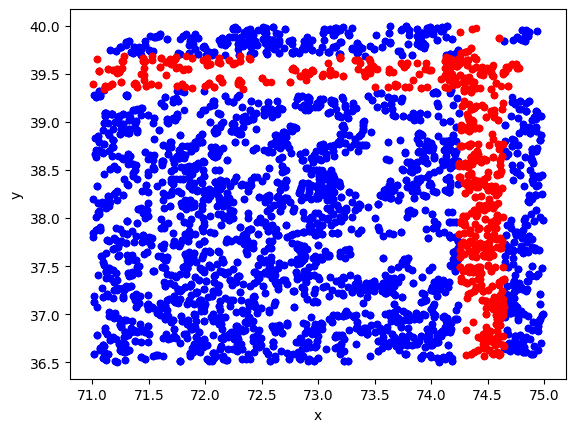

In [191]:
ax = train_X.reset_index().plot.scatter(x='x', y='y', c='b')
ax = test_X.reset_index().plot.scatter(x='x', y='y', c='r', ax=ax)

In [192]:
modelA = ngboost.NGBRegressor(n_estimators=1000, verbose_eval=20, learning_rate=0.01)
modelA.fit(train_X, train_y, test_X, test_y, early_stopping_rounds=50)

test_yhat = modelA.predict(test_X)
metrics.r2_score(test_y, test_yhat)

/home/renku/work/pamir-MLpermafrost/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/renku/work/pamir-MLpermafrost/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[iter 0] loss=2.7473 val_loss=2.5953 scale=1.0000 norm=3.1499
[iter 20] loss=2.6127 val_loss=2.4919 scale=1.0000 norm=2.8081
[iter 40] loss=2.5213 val_loss=2.4113 scale=1.0000 norm=2.5442
[iter 60] loss=2.4498 val_loss=2.3440 scale=1.0000 norm=2.3394
[iter 80] loss=2.3804 val_loss=2.2739 scale=2.0000 norm=4.3207
[iter 100] loss=2.2947 val_loss=2.1828 scale=1.0000 norm=1.9734
[iter 120] loss=2.2186 val_loss=2.1000 scale=2.0000 norm=3.6772
[iter 140] loss=2.1346 val_loss=2.0152 scale=2.0000 norm=3.4339
[iter 160] loss=2.0635 val_loss=1.9520 scale=2.0000 norm=3.2739
[iter 180] loss=2.0150 val_loss=1.9125 scale=2.0000 norm=3.1810
[iter 200] loss=1.9751 val_loss=1.8862 scale=1.0000 norm=1.5549
[iter 220] loss=1.9486 val_loss=1.8701 scale=1.0000 norm=1.5334
[iter 240] loss=1.9261 val_loss=1.8591 scale=1.0000 norm=1.5158
[iter 260] loss=1.9047 val_loss=1.8494 scale=1.0000 norm=1.4994
[iter 280] loss=1.8880 val_loss=1.8418 scale=1.0000 norm=1.4869
[iter 300] loss=1.8709 val_loss=1.8356 scale=1

0.7306565539846248

In [193]:
y_dists_avg, y_dists_std = modelA.pred_dist(test_X).params.values()
y_dists_avg = pd.Series(y_dists_avg, index=test_y.index).rename('average')
y_dists_std = pd.Series(y_dists_std, index=test_y.index).rename('stdev')
# y_resid = abs(test_y - y_dists_avg).rename('residuals')

In [194]:
modelB = trees.ExtraTreesRegressor(n_estimators=200, n_jobs=-1, min_samples_split=4, min_samples_leaf=3)
# modelB = trees.HistGradientBoostingRegressor(max_iter=500)
modelB.fit(train_X, train_y)

train_yhat = modelB.predict(train_X)
test_yhat = modelB.predict(test_X)
metrics.r2_score(test_y, test_yhat), metrics.r2_score(train_y, train_yhat)

/home/renku/work/pamir-MLpermafrost/.venv/lib/python3.12/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


(0.7149703665335125, 0.8811603811547902)

In [209]:
%%time
predictors = cfg.data.inference.load().compute().set_index(['y', 'x'])#.loc[((slice(38.5,40),),slice(71, 73.5)),]
x = cfg.preprocessing.inference(predictors)

CPU times: user 4.82 s, sys: 2.68 s, total: 7.49 s
Wall time: 4.86 s


In [210]:
mask = x.surface_index.to_xarray() > 0

In [211]:
def predict(model, x_subset):
    yhat, ystd = model.pred_dist(x_subset).params.values()
    yhat = pd.Series(yhat, index=x_subset.index).rename('yhat')
    ystd = pd.Series(ystd, index=x_subset.index).rename('ystd')
    yhat = pd.concat([yhat, ystd], axis=1)
    return yhat

In [ ]:
import joblib

n_batches = 24 * 5
step = x.index.size // n_batches
func = joblib.delayed(predict)
tasks = [func(modelA, x.iloc[i: i + step]) for i in range(0, x.index.size, step)]
worker = joblib.Parallel(n_jobs=-1, verbose=True)
out = worker(tasks)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.


In [ ]:
df_yhat = pd.concat(out, axis=0)
ds_yhat = df_yhat.to_xarray()

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=[11, 4])

pd.Series(dict(zip(x.columns, modelA.feature_importances_[0]))).sort_values(ascending=False).plot.barh(ax=axs[0])
pd.Series(dict(zip(x.columns, modelA.feature_importances_[1]))).sort_values(ascending=False).plot.barh(ax=axs[1], color='C1')

axs[0].set_title('Loc estimation', loc='left')
axs[1].set_title('Scale estimation', loc='left')

fig.tight_layout()

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=[11, 4], sharey=True)

img = ds_yhat.yhat.plot.imshow(robust=True, vmin=-12, vmax=12, center=0, cmap='RdBu_r', ax=axs[0])
img.figure.set_dpi(300)

img = ds_yhat.ystd.where(mask).plot.imshow(robust=True, ax=axs[1])
img.figure.set_dpi(300)

fig.tight_layout()